In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
csv_path = "/srv/marl/nathanwu/runs_raw_metrics_20250923_131027_20250923_213730_wb0_vd_control_fake_wb_fake_lmp_fake_ltp_1.csv"


In [3]:
df = pd.read_csv(csv_path)

In [26]:
controls_df = df.loc[(df["vd"] == -0.006) & (df["walkerbots"] == 0)]
cols_to_consider = list(controls_df.columns)
cols_to_consider.remove(("exp_dir"))
print(cols_to_consider)
controls_df = controls_df.drop_duplicates(cols_to_consider)
controls_df.columns
controls_df["avg_auc_difference"] = controls_df["avg_auc_success"] - controls_df["avg_auc_nontracking"]


controls_df = controls_df.drop(controls_df[controls_df["total_episodes"] != 200].index)
controls_df

['vd', 'large_move_penalty', 'large_turn_penalty', 'food_detection_range', 'walkerbots', 'run', 'total_eating_events', 'total_episodes', 'avg_total_episode_reward', 'eating_events_per_episode', 'avg_auc_success', 'avg_auc_nontracking', 'forward_speed_mean', 'forward_speed_variance', 'forward_speed_entropy', 'forward_speed_median', 'forward_speed_skewness', 'forward_speed_kurtosis', 'forward_speed_mode_values', 'turn_speed_mean', 'turn_speed_variance', 'turn_speed_entropy', 'turn_speed_median', 'turn_speed_skewness', 'turn_speed_kurtosis', 'turn_speed_mode_values', 'move_forward_variance_when_food_detected', 'move_forward_variance_when_no_food_detected', 'move_forward_variance_while_hunting', 'move_forward_variance_while_not_hunting', 'eye_turn_mean', 'eye_turn_var', 'eye_turn_min', 'eye_turn_max', 'vergence_change_mean', 'vergence_change_var', 'vergence_change_min', 'vergence_change_max', 'vergence_change_median', 'vergence_change_95th_percentile', 'vergence_change_5th_percentile']


,exp_dir,vd,large_move_penalty,large_turn_penalty,food_detection_range,walkerbots,run,total_eating_events,total_episodes,avg_total_episode_reward,...,eye_turn_min,eye_turn_max,vergence_change_mean,vergence_change_var,vergence_change_min,vergence_change_max,vergence_change_median,vergence_change_95th_percentile,vergence_change_5th_percentile,avg_auc_difference
5,20250923_173739_1_bao_vd_-0.006_lmp_-0.01_ltp_...,-0.006,0.0,0.0,10.0,0,5,1315.0,200.0,33.34,...,-0.8,0.8,0.0005,0.0245,-0.9739,0.2,0.0,0.1989,-0.1996,0.38
11,20250923_191927_1_bao_vd_-0.006_lmp_-0.01_ltp_...,-0.006,0.0,0.0,10.0,0,7,1286.0,200.0,34.08,...,-0.8,0.8,0.0001,0.0186,-0.9739,0.2,0.0,0.1971,-0.1958,0.12
12,20250923_140033_1_bao_vd_-0.006_lmp_-0.01_ltp_...,-0.006,0.0,0.0,10.0,0,1,1456.0,200.0,41.21,...,-0.8,0.8,0.0006,0.0147,-0.9739,0.2,0.0,0.1954,-0.1973,0.36
15,20250923_154335_1_bao_vd_-0.006_lmp_-0.0_ltp_-...,-0.006,0.0,0.0,10.0,0,3,1341.0,200.0,35.06,...,-0.8,0.8,0.0002,0.0211,-0.9739,0.2,0.0,0.1987,-0.1989,0.28
18,20250923_145750_1_bao_vd_-0.006_lmp_-0.02_ltp_...,-0.006,0.0,0.0,10.0,0,2,1353.0,200.0,34.38,...,-0.8,0.8,0.0008,0.0219,-0.9739,0.2,0.0,0.1984,-0.1976,0.23
21,20250923_164726_1_bao_vd_-0.006_lmp_-0.01_ltp_...,-0.006,0.0,0.0,10.0,0,4,1535.0,200.0,41.03,...,-0.8,0.8,0.0004,0.0227,-0.9739,0.2,0.0,0.1990,-0.1992,0.45
24,20250923_131031_1_bao_vd_-0.006_lmp_-0.01_ltp_...,-0.006,0.0,0.0,10.0,0,0,1234.0,200.0,32.60,...,-0.8,0.8,0.0004,0.0206,-0.9739,0.2,0.0,0.1976,-0.1973,-0.35
25,20250923_182925_1_bao_vd_-0.006_lmp_-0.01_ltp_...,-0.006,0.0,0.0,10.0,0,6,1353.0,200.0,35.60,...,-0.8,0.8,0.0002,0.0180,-0.9739,0.2,0.0,0.1982,-0.1979,0.28
29,20250923_200251_1_bao_vd_-0.006_lmp_-0.0_ltp_-...,-0.006,0.0,0.0,10.0,0,8,1220.0,200.0,31.90,...,-0.8,0.8,0.0004,0.0214,-0.9739,0.2,0.0,0.1971,-0.1971,-0.02
34,20250923_155937_1_bao_vd_-0.006_lmp_-0.01_ltp_...,-0.006,0.0,0.0,10.0,0,3,1393.0,200.0,36.03,...,-0.8,0.8,0.0003,0.0238,-0.9739,0.2,0.0,0.1987,-0.1992,0.00


In [27]:
for item in ['vd', 'large_move_penalty', 'large_turn_penalty', 'food_detection_range', 'walkerbots', 'run']:
    cols_to_consider.remove(item)

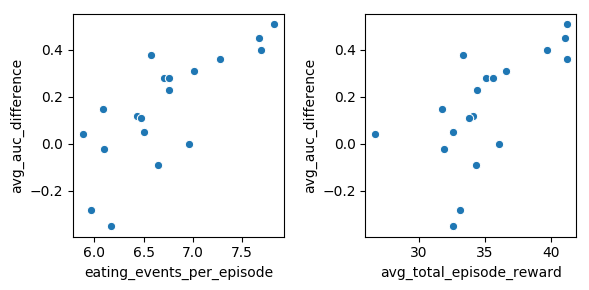

In [29]:
plt.figure(figsize=(6, 3))
plt.subplot(121)
sns.scatterplot(x="eating_events_per_episode", y = "avg_auc_difference", data = controls_df)

plt.subplot(122)
sns.scatterplot(x="avg_total_episode_reward", y = "avg_auc_difference", data = controls_df)
plt.tight_layout()

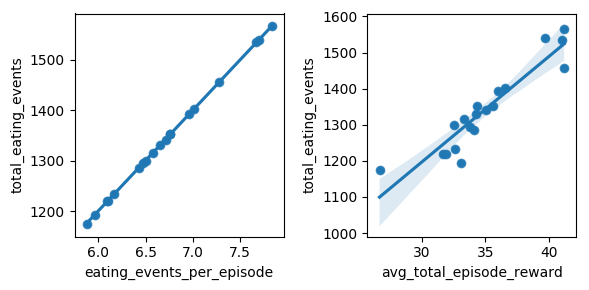

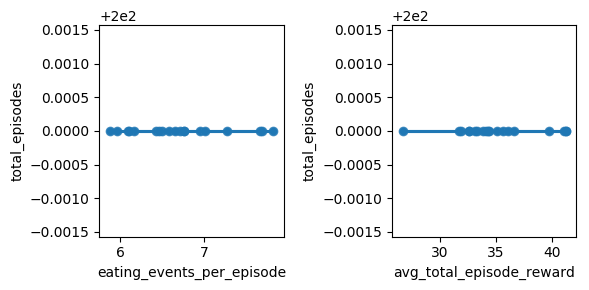

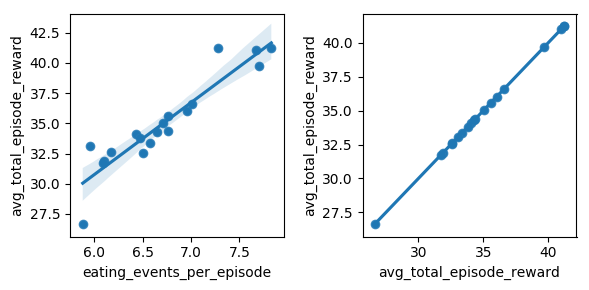

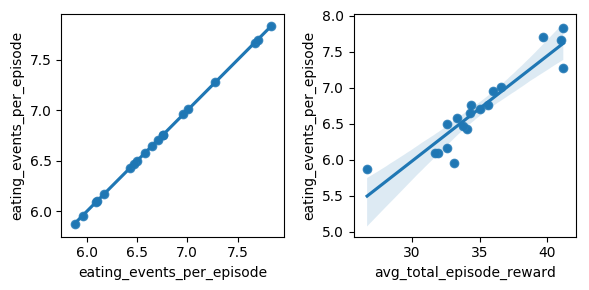

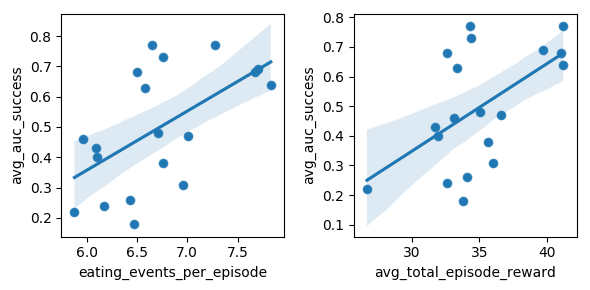

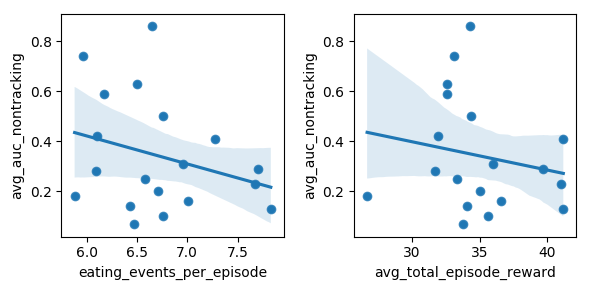

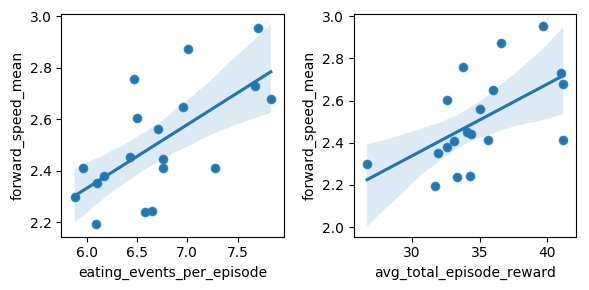

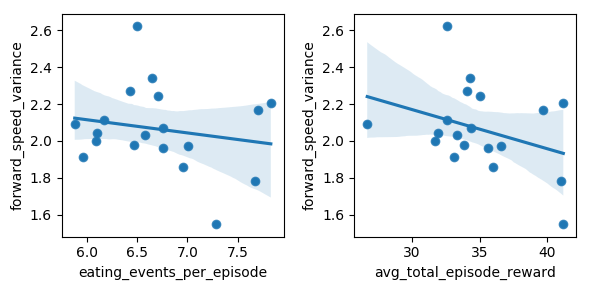

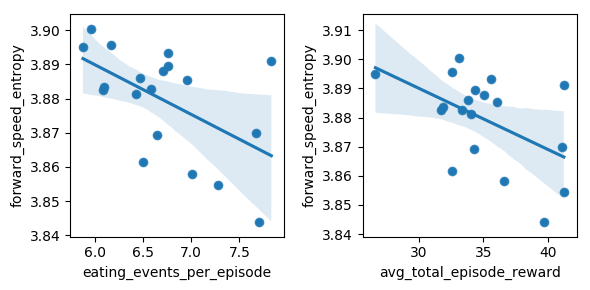

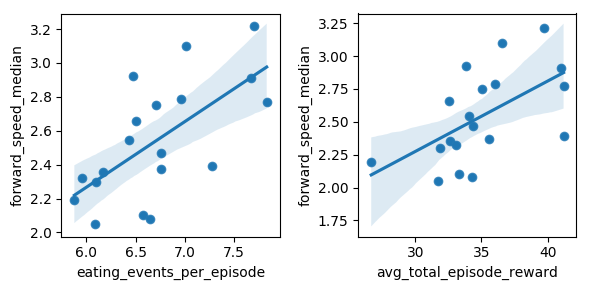

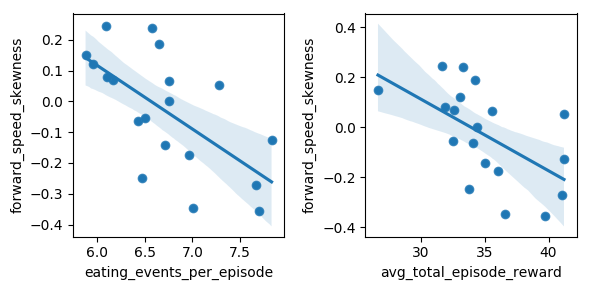

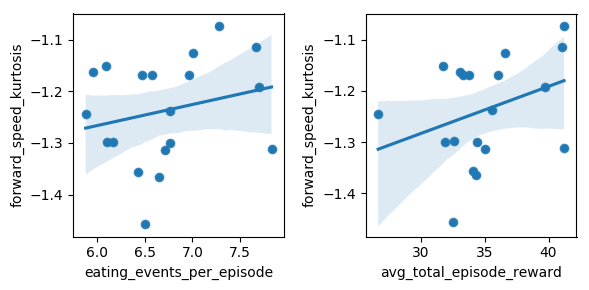

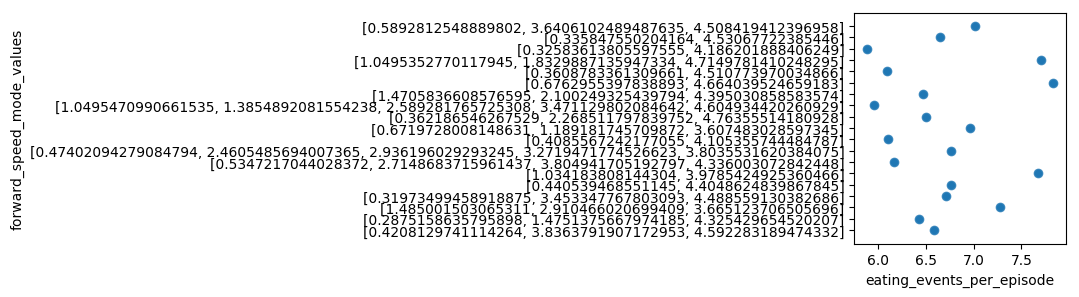

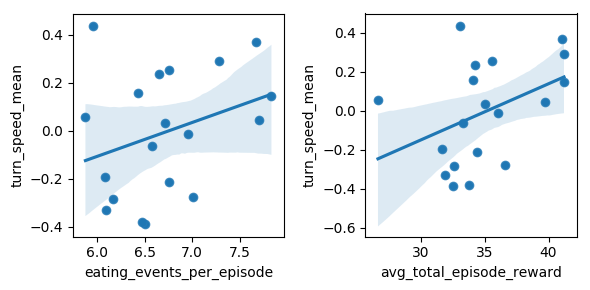

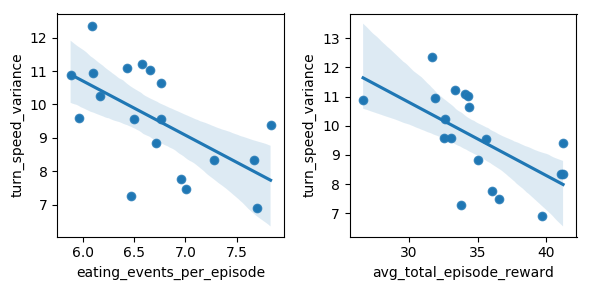

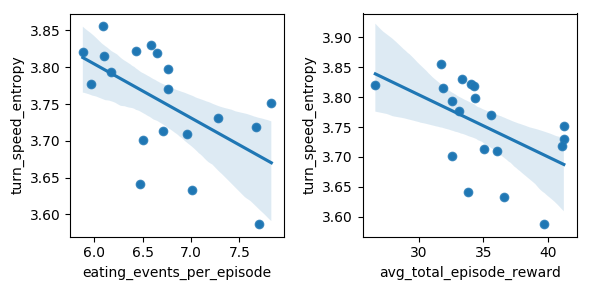

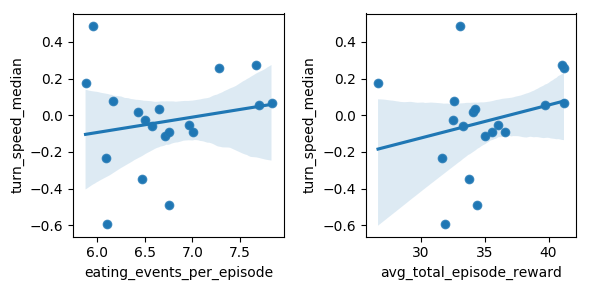

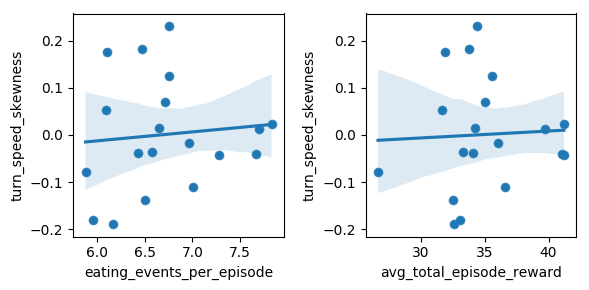

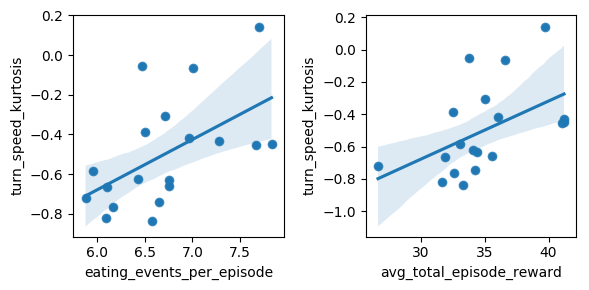

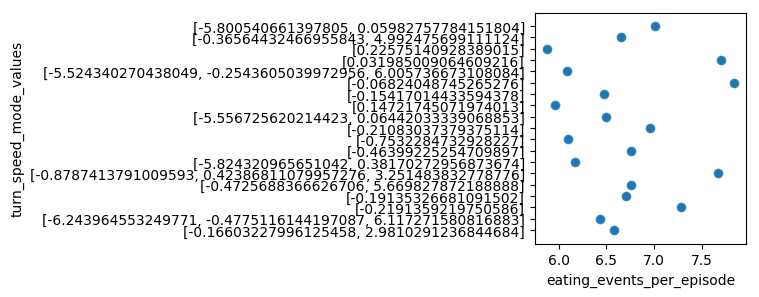

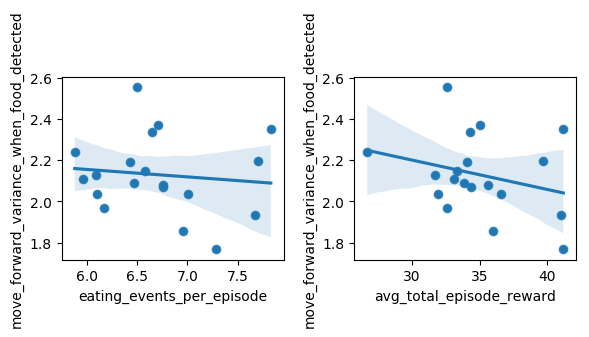

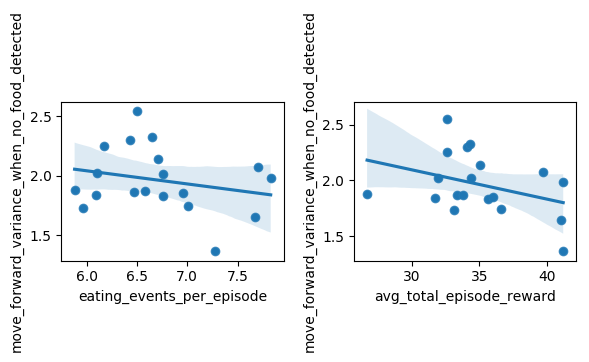

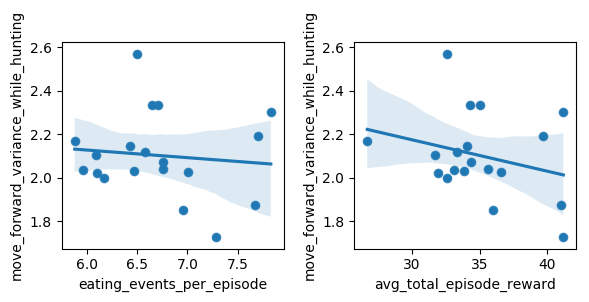

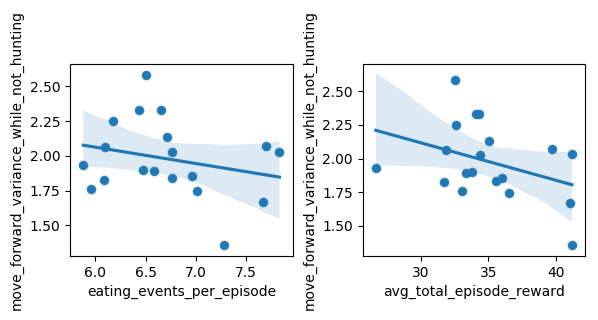

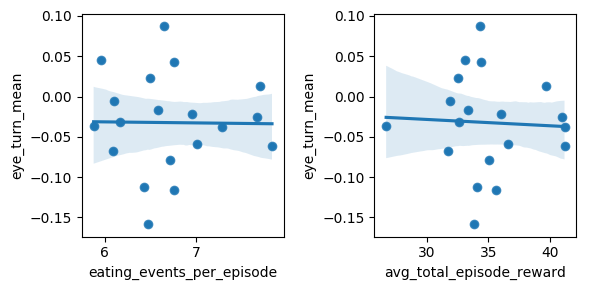

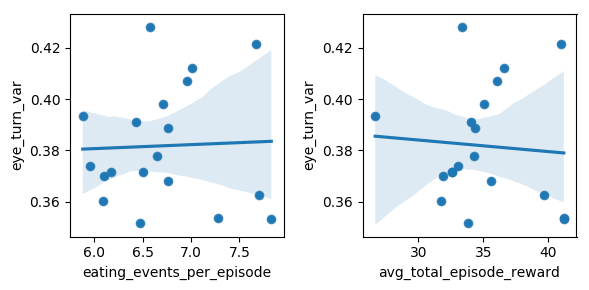

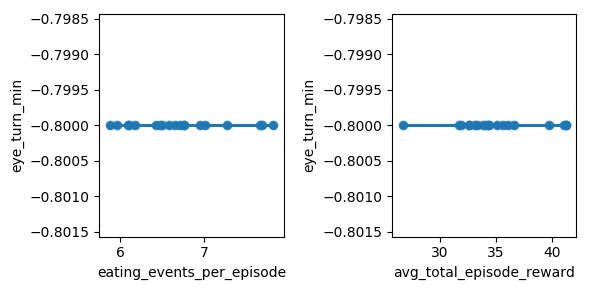

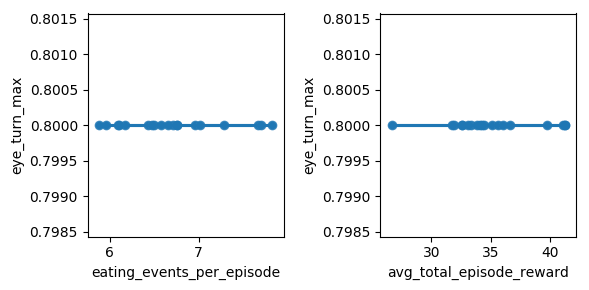

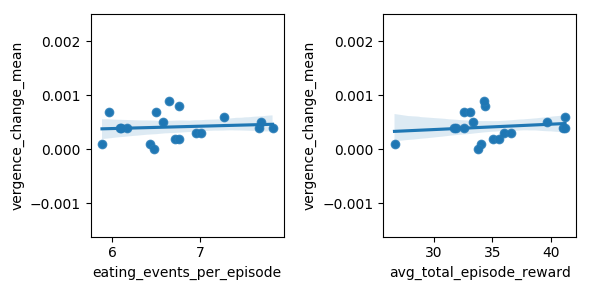

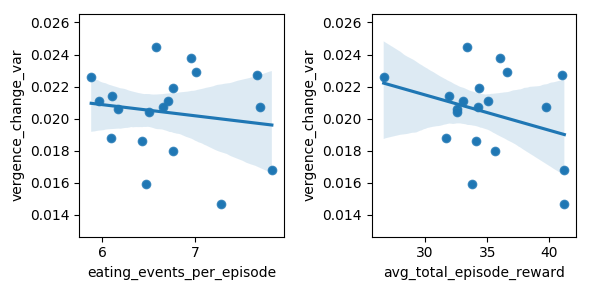

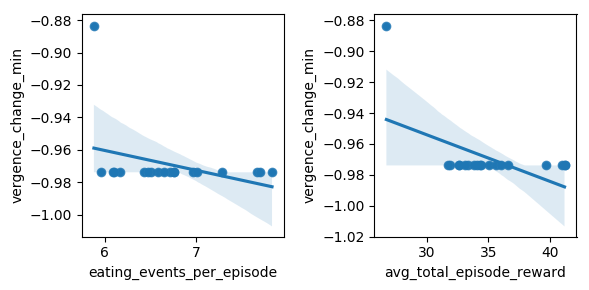

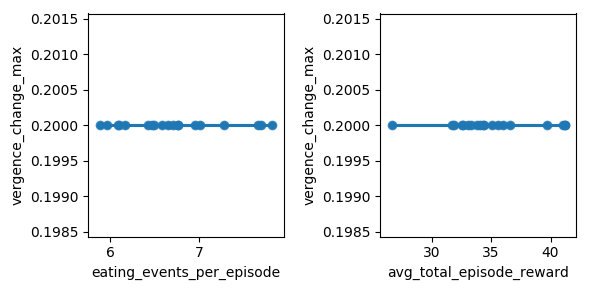

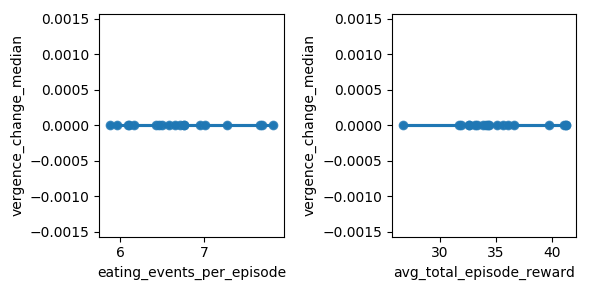

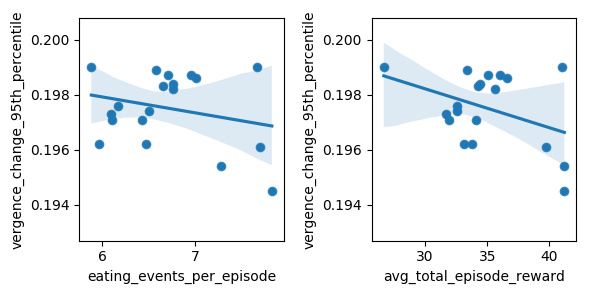

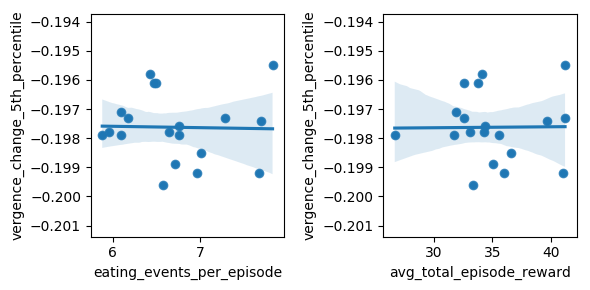

In [32]:
for col in cols_to_consider:
    try:
        plt.figure(figsize=(6, 3))
        plt.subplot(121)
        sns.scatterplot(x="eating_events_per_episode", y = col, data = controls_df)
        sns.regplot(x="eating_events_per_episode", y = col, data = controls_df)

        plt.subplot(122)
        sns.scatterplot(x="avg_total_episode_reward", y = col, data = controls_df)
        sns.regplot(x="avg_total_episode_reward", y = col, data = controls_df)
        plt.tight_layout()
        plt.show()
    except:
        continue



In [ ]:
sns.scatterplot(x="eating_events_per_episode", y = "avg_auc_difference", data = controls_df)